In [1]:
pip install python-constraint

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for python-constraint: filename=python_constraint-1.4.0-py2.py3-none-any.whl size=24138 sha256=dc28678b6a0add4fcd3e678029cc57de482b81751a0ec4448b6024ef18ef963a
  Stored in directory: c:\users\chowd\appdata\local\pip\cache\wheels\f4\b8\c6\1f1e3b56069cb07de800d72df63b47af5ca79bbad5b8952f70
Successfully built python-constraint
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
from constraint import Problem, AllDifferentConstraint
import matplotlib.pyplot as plt
import seaborn as sns

pairs_final = pd.read_csv('../data/processed/pairs_final_with_duty.csv')
top_forbidden = pd.read_csv('../data/processed/top_forbidden_pairs_FINAL.csv')

print("Pairs loaded:", pairs_final.shape)
print("Forbidden pairs:", top_forbidden.shape)
print(top_forbidden.head())

Pairs loaded: (6336, 19)
Forbidden pairs: (528, 7)
  airport_A airport_B  avg_SHIELD_final  avg_pair_risk  avg_duty_risk  \
0       SEA       SFO          0.632525       0.279583       0.607592   
1       PDX       SFO          0.623317       0.287133       0.590392   
2       SAN       SFO          0.623225       0.304217       0.573725   
3       LGA       SFO          0.619542       0.300267       0.573692   
4       PDX       SEA          0.612083       0.275075       0.590392   

   duty_violations  worst_month  
0              0.0         2630  
1              0.0         2591  
2              0.0         2621  
3              0.0         2483  
4              0.0         2590  


In [2]:
# Threshold: pairs with SHIELD final score > 0.55 are FORBIDDEN
FORBIDDEN_THRESHOLD = 0.55

forbidden_set = set()
for _, row in top_forbidden.iterrows():
    if row['avg_SHIELD_final'] >= FORBIDDEN_THRESHOLD:
        forbidden_set.add((row['airport_A'], row['airport_B']))
        forbidden_set.add((row['airport_B'], row['airport_A']))  # bidirectional

print(f"Total forbidden pairs: {len(forbidden_set) // 2}")
print("\nForbidden pairs list:")
for a, b in sorted(forbidden_set):
    if a < b:
        print(f"  {a} ↔ {b}")

Total forbidden pairs: 56

Forbidden pairs list:
  BOS ↔ LAX
  BOS ↔ LGA
  BOS ↔ PDX
  BOS ↔ SAN
  BOS ↔ SEA
  BOS ↔ SFO
  DCA ↔ LGA
  DCA ↔ PDX
  DCA ↔ SEA
  DCA ↔ SFO
  FLL ↔ LGA
  FLL ↔ MCO
  FLL ↔ MIA
  FLL ↔ PDX
  FLL ↔ SAN
  FLL ↔ SEA
  FLL ↔ SFO
  JFK ↔ LGA
  JFK ↔ PDX
  JFK ↔ SAN
  JFK ↔ SEA
  JFK ↔ SFO
  LAX ↔ LGA
  LAX ↔ PDX
  LAX ↔ SAN
  LAX ↔ SEA
  LAX ↔ SFO
  LGA ↔ MCO
  LGA ↔ MIA
  LGA ↔ PDX
  LGA ↔ PHL
  LGA ↔ SAN
  LGA ↔ SEA
  LGA ↔ SFO
  LGA ↔ TPA
  MCO ↔ MIA
  MCO ↔ PDX
  MCO ↔ SAN
  MCO ↔ SEA
  MCO ↔ SFO
  MCO ↔ TPA
  MIA ↔ SAN
  MIA ↔ SEA
  MIA ↔ SFO
  PDX ↔ PHL
  PDX ↔ SAN
  PDX ↔ SEA
  PDX ↔ SFO
  PHL ↔ SAN
  PHL ↔ SEA
  PHL ↔ SFO
  SAN ↔ SEA
  SAN ↔ SFO
  SAN ↔ TPA
  SEA ↔ SFO
  SFO ↔ TPA


In [3]:
airports = sorted(pairs_final['airport_A'].unique().tolist())

# Get all unique pairs from your data
all_pairs = top_forbidden[['airport_A', 'airport_B', 'avg_SHIELD_final']].copy()

# Safe pairs = score below threshold
safe_pairs = all_pairs[all_pairs['avg_SHIELD_final'] < FORBIDDEN_THRESHOLD].copy()
safe_pairs = safe_pairs.sort_values('avg_SHIELD_final')

print(f"\nTotal airports: {len(airports)}")
print(f"Safe pairs available: {len(safe_pairs)}")
print(f"\nTop 10 SAFEST pairs:")
print(safe_pairs.head(10)[['airport_A','airport_B','avg_SHIELD_final']].to_string(index=False))


Total airports: 32
Safe pairs available: 472

Top 10 SAFEST pairs:
airport_A airport_B  avg_SHIELD_final
      AUS       SAT          0.181175
      AUS       ELP          0.195700
      AUS       OKC          0.198850
      AUS       PHX          0.204600
      AUS       TUL          0.217633
      AUS       MEM          0.220408
      ELP       SAT          0.221883
      OKC       SAT          0.227133
      PHX       SAT          0.231408
      AUS       BNA          0.236767


In [4]:
def build_monthly_safe_schedule(month, pairs_df, forbidden_set, top_n=10):
    """
    For a given month, find the top N safest A→DFW→B assignments
    that avoid all forbidden pairs.
    """
    month_pairs = pairs_df[pairs_df['month'] == month].copy()
    
    # Remove forbidden
    def is_safe(row):
        return (row['airport_A'], row['airport_B']) not in forbidden_set and \
               (row['airport_B'], row['airport_A']) not in forbidden_set
    
    safe = month_pairs[month_pairs.apply(is_safe, axis=1)].copy()
    safe = safe.sort_values('SHIELD_final_score').head(top_n)
    safe['month'] = month
    return safe

# Build schedule for all 12 months
all_schedules = []
for month in range(1, 13):
    schedule = build_monthly_safe_schedule(month, pairs_final, forbidden_set, top_n=10)
    all_schedules.append(schedule)

monthly_schedule = pd.concat(all_schedules, ignore_index=True)
print(f"Total safe assignments across all months: {len(monthly_schedule)}")
print(monthly_schedule[['airport_A','airport_B','month',
                         'SHIELD_final_score','duty_buffer_hours']].head(20).to_string(index=False))

Total safe assignments across all months: 120
airport_A airport_B  month  SHIELD_final_score  duty_buffer_hours
      AUS       SAT      1              0.2305              11.24
      AUS       TUL      1              0.2362              10.99
      AUS       PHX      1              0.2375               9.99
      AUS       ELP      1              0.2587              10.74
      PHX       SAT      1              0.2826               9.74
      AUS       OKC      1              0.2856              10.99
      SAT       TUL      1              0.2928              10.70
      AUS       MEM      1              0.2937              10.74
      PHX       TUL      1              0.2942               9.49
      AUS       MSP      1              0.3100               9.99
      AUS       SAT      2              0.0596              11.23
      ELP       SAT      2              0.0922              10.50
      IAH       SAT      2              0.0933              10.75
      AUS       ELP      2    

In [5]:
# Best single pair recommendation per month
best_per_month = (
    monthly_schedule
    .sort_values('SHIELD_final_score')
    .groupby('month')
    .first()
    .reset_index()
)

print("\n=== SHIELD RECOMMENDED SAFE SEQUENCE PER MONTH ===")
print(best_per_month[['month','airport_A','airport_B',
                       'SHIELD_final_score','duty_buffer_hours',
                       'total_sequence_hours']].to_string(index=False))


=== SHIELD RECOMMENDED SAFE SEQUENCE PER MONTH ===
 month airport_A airport_B  SHIELD_final_score  duty_buffer_hours  total_sequence_hours
     1       AUS       SAT              0.2305              11.24                  2.76
     2       AUS       SAT              0.0596              11.23                  2.77
     3       AUS       TUL              0.2156              10.96                  3.04
     4       AUS       ELP              0.2397              10.70                  3.30
     5       ELP       PHX              0.4200               9.20                  4.80
     6       AUS       SAT              0.1968              11.23                  2.77
     7       AUS       ELP              0.1111              10.73                  3.27
     8       AUS       SAT              0.1241              11.24                  2.76
     9       AUS       SAT              0.0000              11.24                  2.76
    10       AUS       OKC              0.0143              10.98   

In [6]:
monthly_schedule.to_csv('../data/processed/safe_schedule_csp.csv', index=False)
best_per_month.to_csv('../data/processed/best_monthly_recommendation.csv', index=False)
print("✅ CSP outputs saved!")

✅ CSP outputs saved!


FileNotFoundError: [Errno 2] No such file or directory: '../report/forbidden_vs_safe_pairs.png'

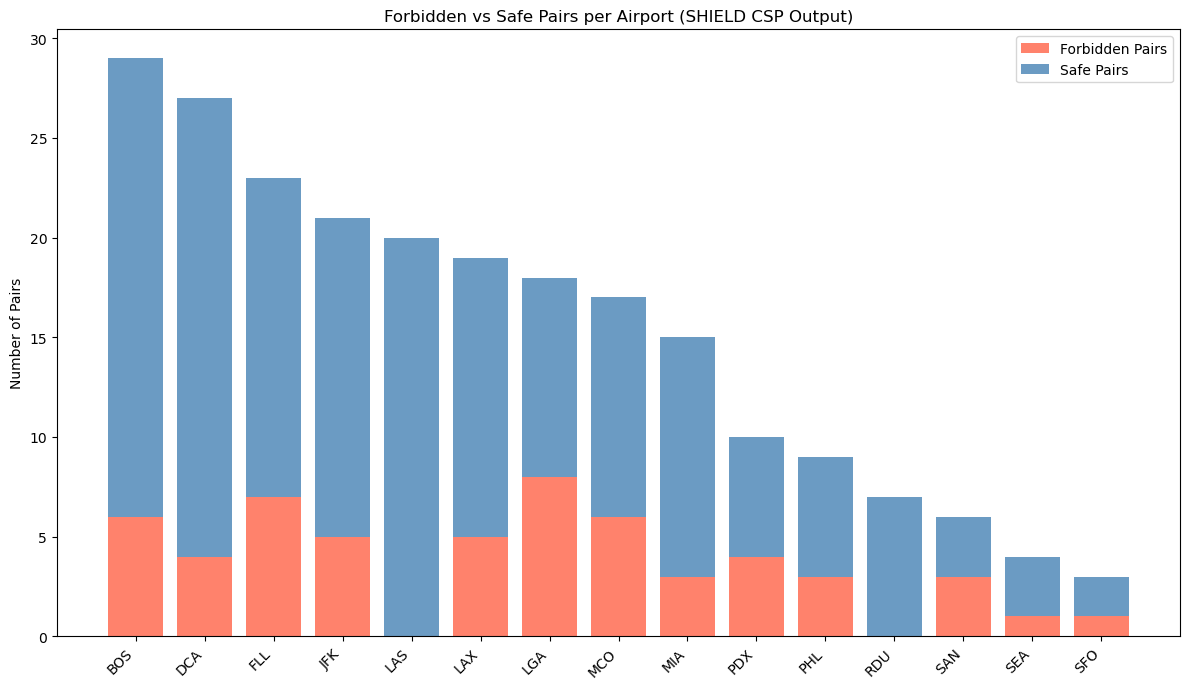

In [7]:
# Count forbidden vs safe per airport
all_pair_counts = top_forbidden.copy()
all_pair_counts['status'] = all_pair_counts['avg_SHIELD_final'].apply(
    lambda x: 'Forbidden' if x >= FORBIDDEN_THRESHOLD else 'Safe'
)

status_counts = all_pair_counts.groupby(['airport_A', 'status']).size().unstack(fill_value=0).reset_index()

# Top 15 airports
top15 = top_forbidden.groupby('airport_A')['avg_SHIELD_final'].mean().nlargest(15).index
status_top = status_counts[status_counts['airport_A'].isin(top15)]

fig, ax = plt.subplots(figsize=(12, 7))
x = range(len(status_top))
if 'Forbidden' in status_top.columns:
    ax.bar(x, status_top['Forbidden'], label='Forbidden Pairs', color='tomato', alpha=0.8)
if 'Safe' in status_top.columns:
    ax.bar(x, status_top.get('Safe', 0),
           bottom=status_top.get('Forbidden', 0),
           label='Safe Pairs', color='steelblue', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(status_top['airport_A'].tolist(), rotation=45, ha='right')
ax.set_title('Forbidden vs Safe Pairs per Airport (SHIELD CSP Output)')
ax.set_ylabel('Number of Pairs')
ax.legend()
plt.tight_layout()
plt.savefig('../report/forbidden_vs_safe_pairs.png', dpi=200)
plt.show()
print("✅ Chart saved!")

FileNotFoundError: [Errno 2] No such file or directory: '../report/monthly_safe_recommendations.png'

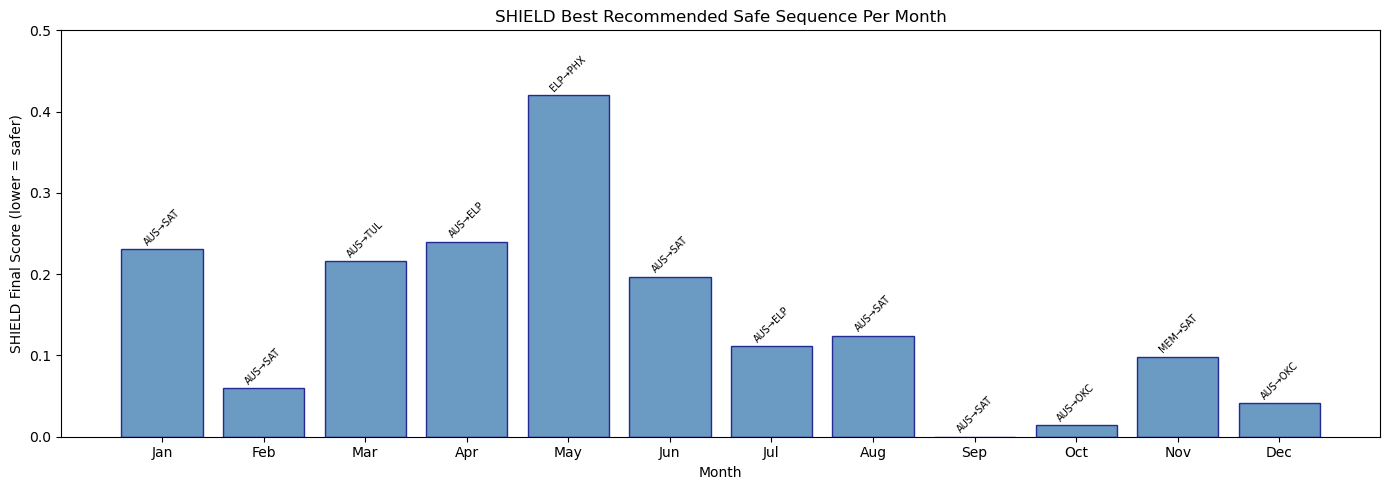

In [8]:
pivot_safe = best_per_month.copy()
pivot_safe['pair_label'] = pivot_safe['airport_A'] + '→' + pivot_safe['airport_B']

plt.figure(figsize=(14, 5))
plt.bar(pivot_safe['month'], pivot_safe['SHIELD_final_score'],
        color='steelblue', edgecolor='navy', alpha=0.8)
plt.xticks(range(1, 13),
           ['Jan','Feb','Mar','Apr','May','Jun',
            'Jul','Aug','Sep','Oct','Nov','Dec'])
for i, row in pivot_safe.iterrows():
    plt.text(row['month'], row['SHIELD_final_score'] + 0.005,
             row['pair_label'], ha='center', fontsize=7, rotation=45)
plt.title('SHIELD Best Recommended Safe Sequence Per Month')
plt.xlabel('Month')
plt.ylabel('SHIELD Final Score (lower = safer)')
plt.ylim(0, 0.5)
plt.tight_layout()
plt.savefig('../report/monthly_safe_recommendations.png', dpi=200)
plt.show()
print("✅ Monthly schedule chart saved!")